In [24]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=netCDF['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=netCDF.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=netCDF['time']
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF
# data=netCDF.isel(time=np.arange(0,140+1))
# parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [25]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [4]:
if res=='1km':
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
if res=='250m':
    dir2='/mnt/lustre/koa/scratch/air673/'
def initiate_array():
    # Define array dimensions (adjust based on your netCDF)
    t_size = len(netCDF['time'])  # Number of timesteps
    z_size = len(netCDF['zh'])    # Number of vertical levels
    y_size = len(netCDF['yh'])    # Number of y-axis points
    x_size = len(netCDF['xh'])    # Number of x-axis points
    
    with h5py.File(dir2 + 'Variable_Calculation/' + '3D_Moisture_Convergence'+f'_{res}_{Np_str}'+'.h5', 'a') as f:
        # Check if the dataset 'theta_e' already exists
        if 'conv' not in f:
            # Create a dataset with the full size for all time steps (initially empty)
            f.create_dataset('conv', 
                             (t_size, z_size, y_size, x_size),  # Full size for all timesteps
                             maxshape=(None, z_size, y_size, x_size),  # Unlimited timesteps (can grow along time dimension)
                             dtype='float64', 
                             chunks=(1, z_size, y_size, x_size))  # Chunks for time axis to allow resizing

            
def add_timestep_at_index(timestep_data, index):
    with h5py.File(dir2 + 'Variable_Calculation/' + '3D_Moisture_Convergence'+f'_{res}_{Np_str}'+'.h5', 'a') as f:
        # Access the existing dataset 'theta_e'
        dataset = f['conv']
        
        # Assign the new timestep data at the specified index
        dataset[index] = timestep_data

In [ ]:
#FROM MOISTURE FLUX CONVERGENCE: ITS HISTORY AND APPLICATION IN CONVECTIVE INITIATION FORECASTING
# Peter C. Banacos
# NOAA/NWS/NCEP/Storm Prediction Center
# Norman, Oklahoma 73069
# David M. Schultz
# Cooperative Institute for Mesoscale Meteorological Studies, Univ. of Oklahoma, and
# NOAA/National Severe Storms Laboratory, Norman, Oklahoma 73069

In [65]:
########################################################################
#3D MOISTURE FLUX CONVERGENCE CALCULATION
#MOISTURE ADVECTION + MOISTURE * DIVERGENCE

In [8]:
#MAKING ARRAY TO STORE MFC
# WITHOUT ADVECTION + CONVERGENCE IDENTIY
initiate_array()

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(len(netCDF['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    if Np_str=='125e3':
        u_data=data['u'].isel(time=t).interp(xf=data['xh']).data
        v_data=data['v'].isel(time=t).interp(yf=data['yh']).data
        w_data=data['w'].isel(time=t).interp(zf=data['zh']).data
        qv_data=data['qv'].isel(time=t).data
    elif Np_str=='1e6':
        u_data=data['uinterp'].isel(time=t).data
        v_data=data['vinterp'].isel(time=t).data
        w_data=data['winterp'].isel(time=t).data
        qv_data=data['qv'].isel(time=t).data
        
    print('calculating convergence and taking mean')
    one=u_data*Ddx_3D(qv_data,1000)
    two=v_data*Ddy_3D(qv_data,1000)
    three=w_data*Ddz_3DStretch(qv_data,data)
    
    four=qv_data*Ddx_3D(u_data,1000)
    five=qv_data*Ddy_3D(v_data,1000)
    six=qv_data*Ddz_3DStretch(w_data,data)
    
    conv=-(one+two+three)-(four+five+six)
    add_timestep_at_index(conv, t)


Current time 0
calculating convergence and taking mean
Current time 1
calculating convergence and taking mean
Current time 2
calculating convergence and taking mean
Current time 3
calculating convergence and taking mean
Current time 4
calculating convergence and taking mean
Current time 5
calculating convergence and taking mean
Current time 6
calculating convergence and taking mean
Current time 7
calculating convergence and taking mean
Current time 8
calculating convergence and taking mean
Current time 9
calculating convergence and taking mean
Current time 10
calculating convergence and taking mean
Current time 11
calculating convergence and taking mean
Current time 12
calculating convergence and taking mean
Current time 13
calculating convergence and taking mean
Current time 14
calculating convergence and taking mean
Current time 15
calculating convergence and taking mean
Current time 16
calculating convergence and taking mean
Current time 17
calculating convergence and taking mean
Cu

In [28]:
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
file_path = dir2 + 'Variable_Calculation/' + '3D_Moisture_Convergence' + f'_{res}_{Np_str}' + '.h5'
with h5py.File(file_path, 'r') as f:
    Conv= f['conv'][:]

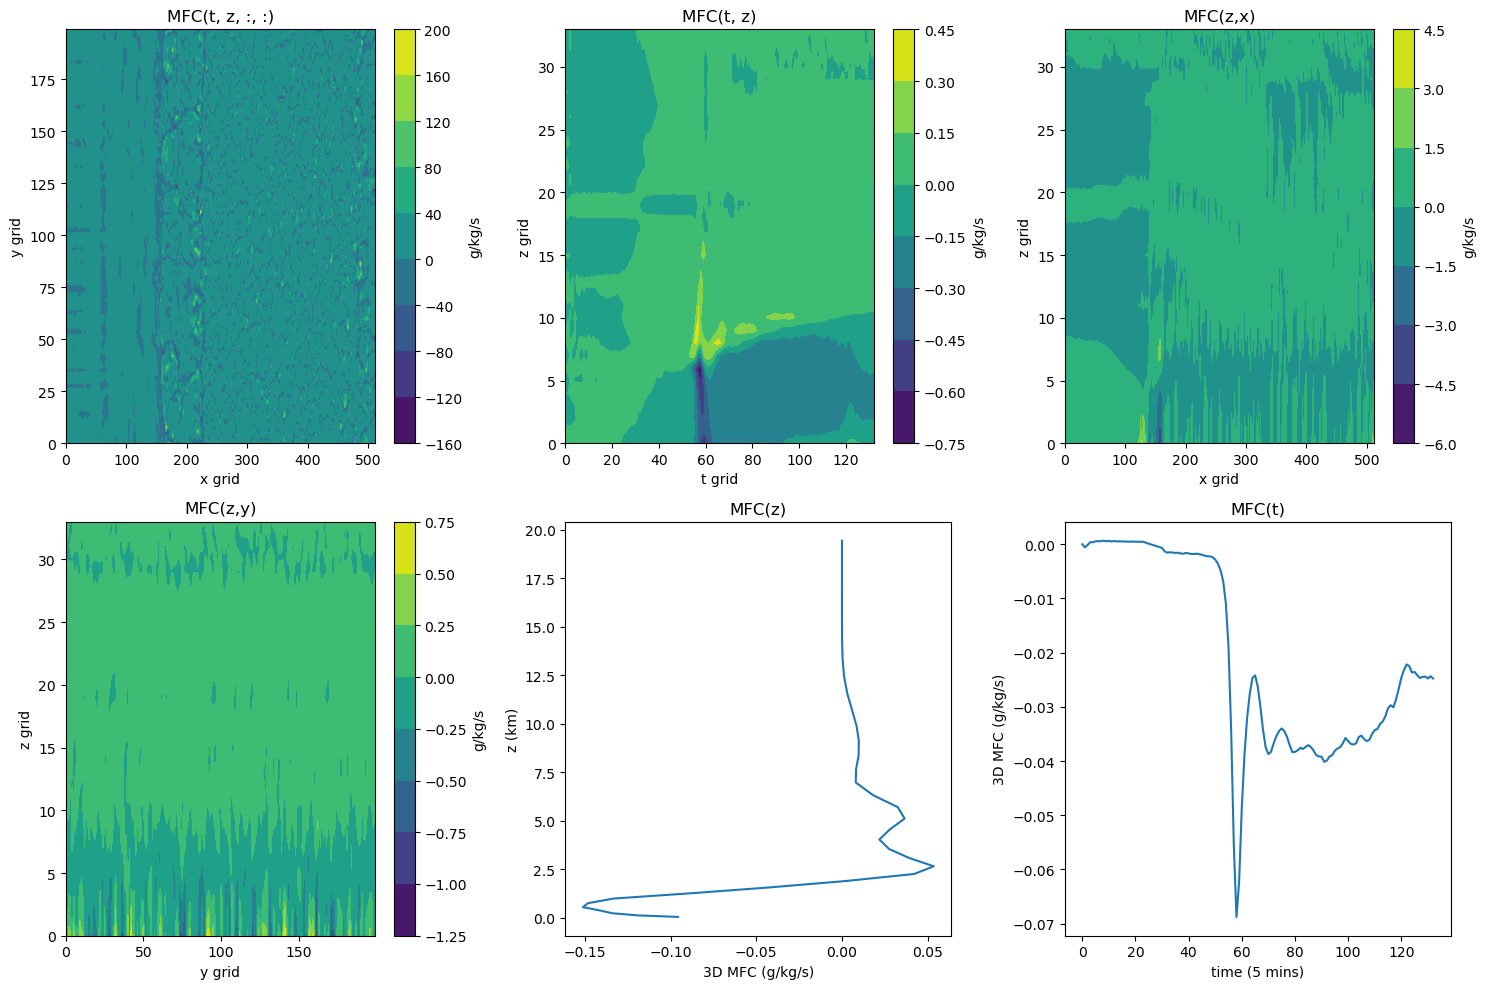

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

t=100;z=3

# Assuming Conv and data are already defined and properly loaded

# Create a 2x3 subplot grid using GridSpec
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3)

# Plot 1: Contourf for Conv[t, z]
ax1 = fig.add_subplot(gs[0, 0])
MFC_3D = Conv[t, z] 
c1 = ax1.contourf(MFC_3D* 1000)
ax1.set_xlabel('x grid')
ax1.set_ylabel('y grid')
ax1.set_title('MFC(t, z, :, :)')

# Plot 2: Contourf for MFC_tz (mean over axis (2, 3))
ax2 = fig.add_subplot(gs[0, 1])
MFC_tz = np.mean(Conv, axis=(2, 3))
c2 = ax2.contourf(MFC_tz.T * 1000)
ax2.set_xlabel('t grid')
ax2.set_ylabel('z grid')
ax2.set_title('MFC(t, z)')

# Plot 3: Contourf for MFC_tz (mean over axis (0, 2))
ax3 = fig.add_subplot(gs[0, 2])
MFC_zx = np.mean(Conv, axis=(0, 2))
c3 = ax3.contourf(MFC_zx * 1000)
ax3.set_xlabel('x grid')
ax3.set_ylabel('z grid')
ax3.set_title('MFC(z,x)')

# Plot 4: Contourf for MFC_tz (mean over axis (0, 3))
ax4 = fig.add_subplot(gs[1, 0])
MFC_zy = np.mean(Conv, axis=(0, 3))
c4 = ax4.contourf(MFC_zy * 1000)
ax4.set_xlabel('y grid')
ax4.set_ylabel('z grid')
ax4.set_title('MFC(z,y)')

# Plot 5: Plot of MFC_z (mean over axis (0, 2, 3))
ax5 = fig.add_subplot(gs[1, 1])
MFC_z = np.mean(Conv, axis=(0, 2, 3))
ax5.plot(MFC_z * 1000, data['zh'])
ax5.set_xlabel('3D MFC (g/kg/s)')
ax5.set_ylabel('z (km)')
ax5.set_title('MFC(z)')

# Plot 6: Time plot of MFC_z (mean over axis (1, 2, 3))
ax6 = fig.add_subplot(gs[1, 2])
MFC_t = np.mean(Conv, axis=(1, 2, 3))
ts = np.arange(len(data['time']))
ax6.plot(ts, MFC_t * 1000)
ax6.set_xlabel('time (5 mins)')
ax6.set_ylabel('3D MFC (g/kg/s)')
ax6.set_title('MFC(t)')

# Add colorbars with scientific notation
cb1 = fig.colorbar(c1, ax=ax1, label='g/kg/s')
cb2 = fig.colorbar(c2, ax=ax2, label='g/kg/s')
cb3 = fig.colorbar(c3, ax=ax3, label='g/kg/s')
cb4 = fig.colorbar(c4, ax=ax4, label='g/kg/s')

# Apply scientific notation to the colorbar
for cb in [cb1, cb2, cb3, cb4]:
    cb.formatter = ScalarFormatter()
    cb.formatter.set_powerlimits((-3, 4))  # Set the range for scientific notation
    cb.update_ticks()

# Adjust layout for better spacing
plt.tight_layout()

In [ ]:
################################################################

In [11]:
if res=='1km':
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
if res=='250m':
    dir2='/mnt/lustre/koa/scratch/air673/'
def initiate_array():
    # Define array dimensions (adjust based on your netCDF)
    t_size = len(netCDF['time'])  # Number of timesteps
    z_size = len(netCDF['zh'])    # Number of vertical levels
    y_size = len(netCDF['yh'])    # Number of y-axis points
    x_size = len(netCDF['xh'])    # Number of x-axis points
    
    with h5py.File(dir2 + 'Variable_Calculation/' + '3D_Moisture_Convergence'+f'_{res}_{Np_str}_2'+'.h5', 'a') as f:
        # Check if the dataset 'theta_e' already exists
        if 'conv' not in f:
            # Create a dataset with the full size for all time steps (initially empty)
            f.create_dataset('conv', 
                             (t_size, z_size, y_size, x_size),  # Full size for all timesteps
                             maxshape=(None, z_size, y_size, x_size),  # Unlimited timesteps (can grow along time dimension)
                             dtype='float64', 
                             chunks=(1, z_size, y_size, x_size))  # Chunks for time axis to allow resizing

            
def add_timestep_at_index(timestep_data, index):
    with h5py.File(dir2 + 'Variable_Calculation/' + '3D_Moisture_Convergence'+f'_{res}_{Np_str}_2'+'.h5', 'a') as f:
        # Access the existing dataset 'theta_e'
        dataset = f['conv']
        
        # Assign the new timestep data at the specified index
        dataset[index] = timestep_data

In [13]:
#MAKING ARRAY TO STORE VARIABLE
# WITHOUT ADVECTION + CONVERGENCE IDENTIY
initiate_array()

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(len(netCDF['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    if Np_str=='1e6':
        u_data=data['uinterp'].isel(time=t).data
        v_data=data['vinterp'].isel(time=t).data
        w_data=data['winterp'].isel(time=t).data
        qv_data=data['qv'].isel(time=t).data
        
    print('calculating convergence and taking mean')
    one=Ddx_3D(qv_data*u_data,1000)
    two=Ddy_3D(qv_data*v_data,1000)
    three=Ddz_3DStretch(qv_data*w_data,data)
    conv=-(one+two+three)
    add_timestep_at_index(conv, t)


Current time 0
calculating convergence and taking mean
Current time 1
calculating convergence and taking mean
Current time 2
calculating convergence and taking mean
Current time 3
calculating convergence and taking mean
Current time 4
calculating convergence and taking mean
Current time 5
calculating convergence and taking mean
Current time 6
calculating convergence and taking mean
Current time 7
calculating convergence and taking mean
Current time 8
calculating convergence and taking mean
Current time 9
calculating convergence and taking mean
Current time 10
calculating convergence and taking mean
Current time 11
calculating convergence and taking mean
Current time 12
calculating convergence and taking mean
Current time 13
calculating convergence and taking mean
Current time 14
calculating convergence and taking mean
Current time 15
calculating convergence and taking mean
Current time 16
calculating convergence and taking mean
Current time 17
calculating convergence and taking mean
Cu

In [26]:
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
file_path = dir2 + 'Variable_Calculation/' + '3D_Moisture_Convergence' + f'_{res}_{Np_str}_2' + '.h5'
with h5py.File(file_path, 'r') as f:
    Conv2= f['conv'][:]

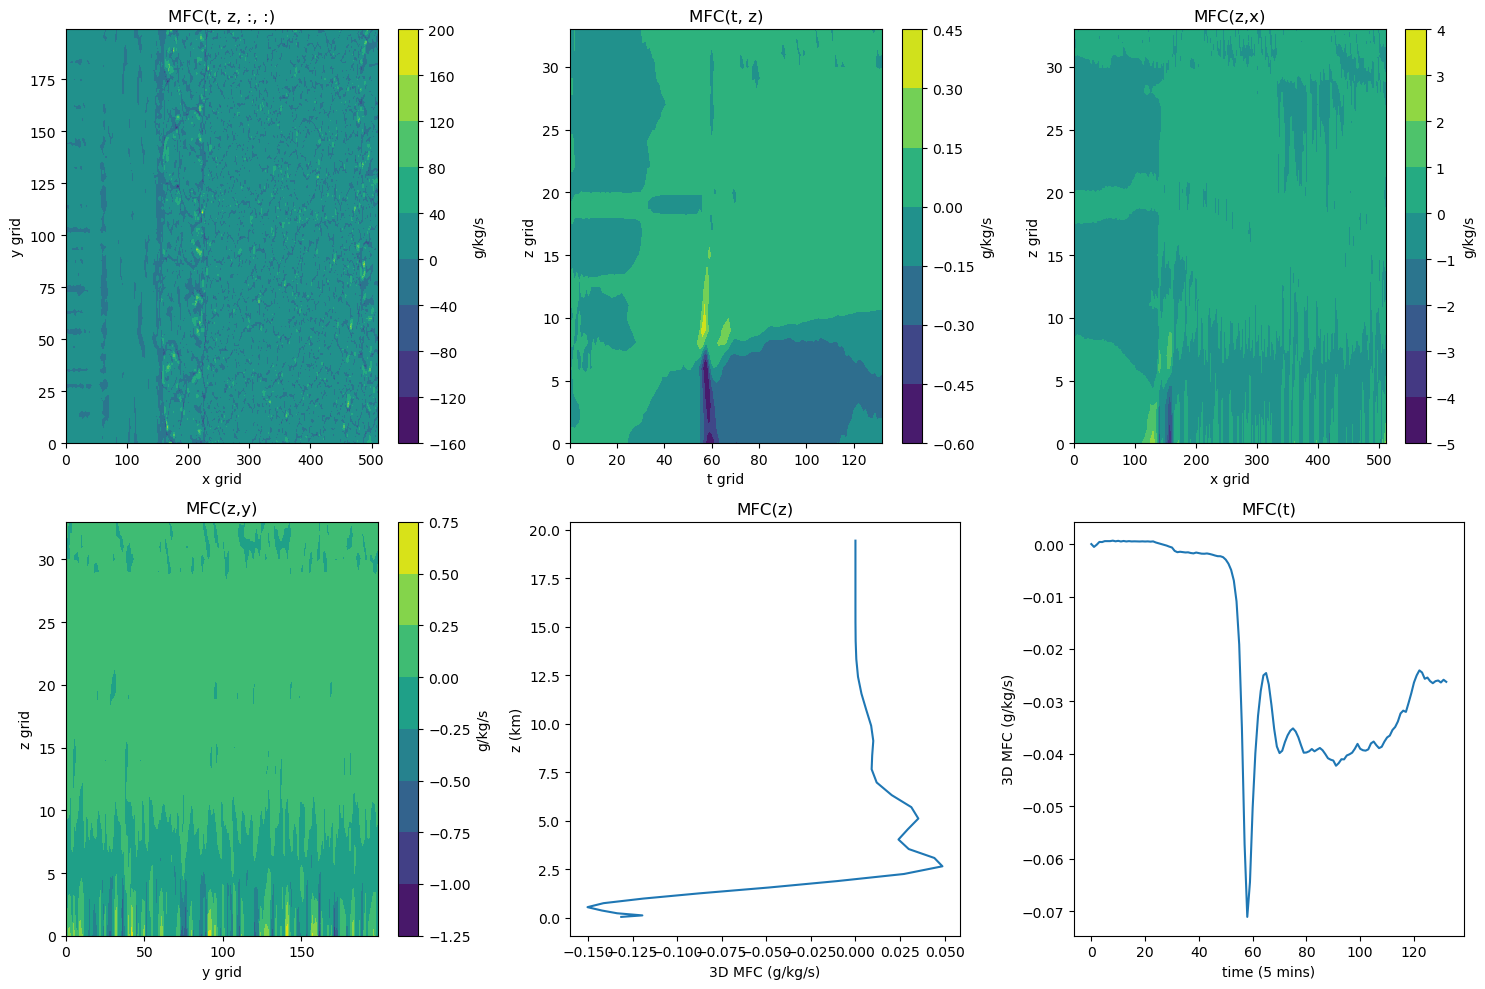

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

t=100;z=3

# Assuming Conv and data are already defined and properly loaded

# Create a 2x3 subplot grid using GridSpec
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3)

# Plot 1: Contourf for Conv[t, z]
ax1 = fig.add_subplot(gs[0, 0])
MFC_3D2 = Conv2[t, z] 
c1 = ax1.contourf(MFC_3D2* 1000)
ax1.set_xlabel('x grid')
ax1.set_ylabel('y grid')
ax1.set_title('MFC(t, z, :, :)')

# Plot 2: Contourf for MFC_tz (mean over axis (2, 3))
ax2 = fig.add_subplot(gs[0, 1])
MFC_tz2 = np.mean(Conv2, axis=(2, 3))
c2 = ax2.contourf(MFC_tz2.T * 1000)
ax2.set_xlabel('t grid')
ax2.set_ylabel('z grid')
ax2.set_title('MFC(t, z)')

# Plot 3: Contourf for MFC_tz (mean over axis (0, 2))
ax3 = fig.add_subplot(gs[0, 2])
MFC_zx2 = np.mean(Conv2, axis=(0, 2))
c3 = ax3.contourf(MFC_zx2 * 1000)
ax3.set_xlabel('x grid')
ax3.set_ylabel('z grid')
ax3.set_title('MFC(z,x)')

# Plot 4: Contourf for MFC_tz (mean over axis (0, 3))
ax4 = fig.add_subplot(gs[1, 0])
MFC_zy2 = np.mean(Conv2, axis=(0, 3))
c4 = ax4.contourf(MFC_zy2 * 1000)
ax4.set_xlabel('y grid')
ax4.set_ylabel('z grid')
ax4.set_title('MFC(z,y)')

# Plot 5: Plot of MFC_z (mean over axis (0, 2, 3))
ax5 = fig.add_subplot(gs[1, 1])
MFC_z2 = np.mean(Conv2, axis=(0, 2, 3))
ax5.plot(MFC_z2 * 1000, data['zh'])
ax5.set_xlabel('3D MFC (g/kg/s)')
ax5.set_ylabel('z (km)')
ax5.set_title('MFC(z)')

# Plot 6: Time plot of MFC_z (mean over axis (1, 2, 3))
ax6 = fig.add_subplot(gs[1, 2])
MFC_t2 = np.mean(Conv2, axis=(1, 2, 3))
ts = np.arange(len(data['time']))
ax6.plot(ts, MFC_t2 * 1000)
ax6.set_xlabel('time (5 mins)')
ax6.set_ylabel('3D MFC (g/kg/s)')
ax6.set_title('MFC(t)')

# Add colorbars with scientific notation
cb1 = fig.colorbar(c1, ax=ax1, label='g/kg/s')
cb2 = fig.colorbar(c2, ax=ax2, label='g/kg/s')
cb3 = fig.colorbar(c3, ax=ax3, label='g/kg/s')
cb4 = fig.colorbar(c4, ax=ax4, label='g/kg/s')

# Apply scientific notation to the colorbar
for cb in [cb1, cb2, cb3, cb4]:
    cb.formatter = ScalarFormatter()
    cb.formatter.set_powerlimits((-3, 4))  # Set the range for scientific notation
    cb.update_ticks()

# Adjust layout for better spacing
plt.tight_layout()

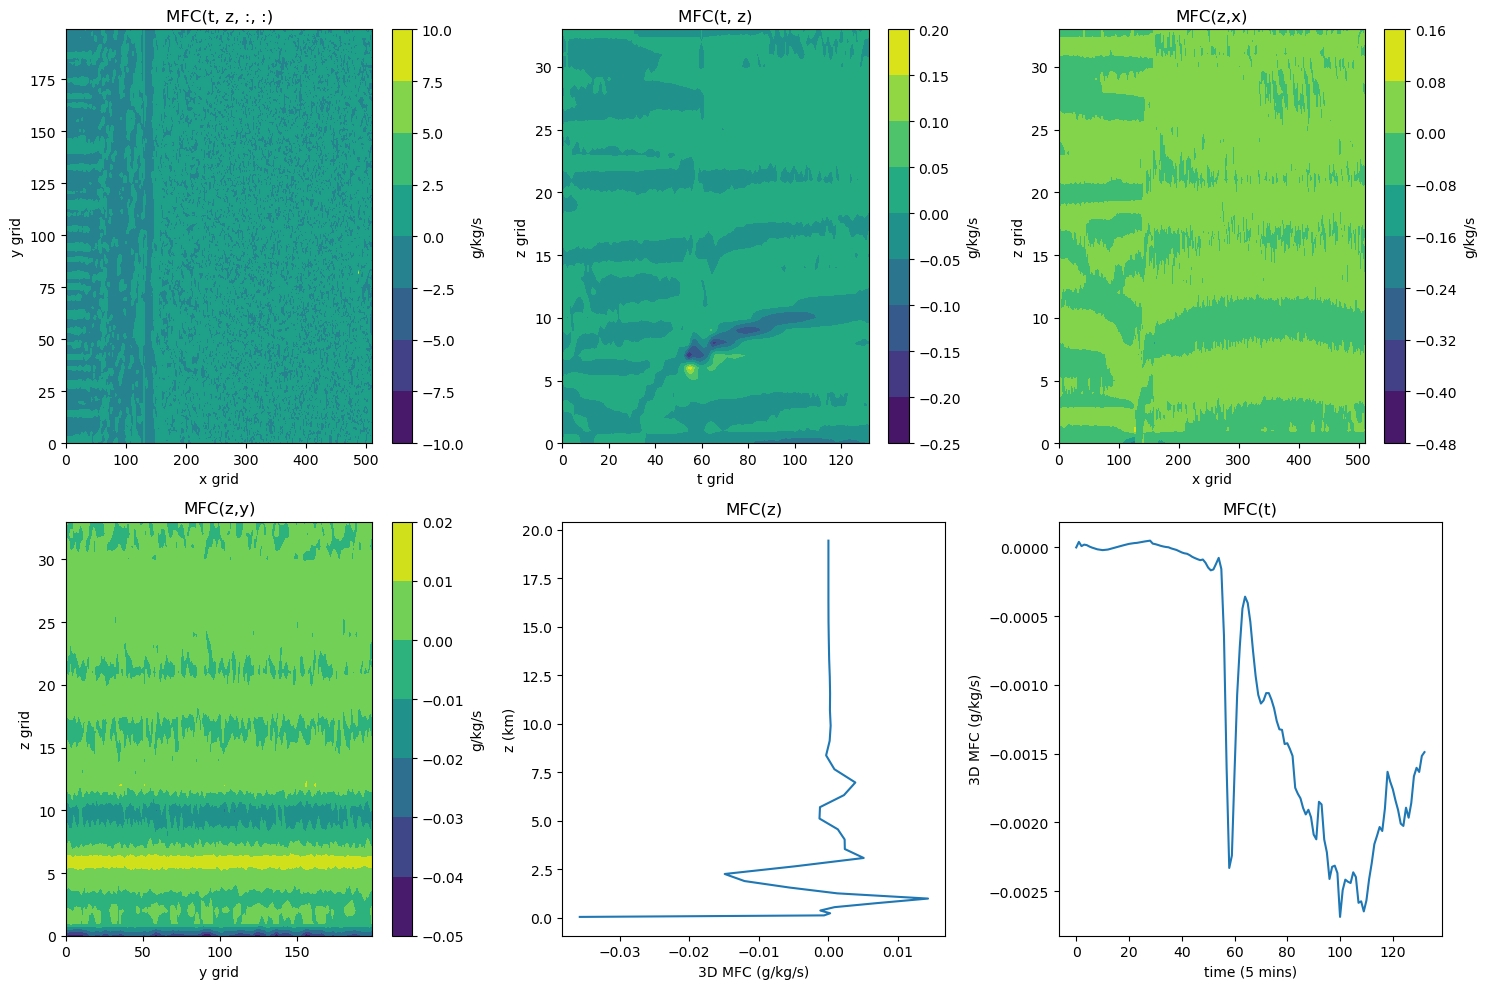

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

t=100;z=3

# Assuming Conv and data are already defined and properly loaded

# Create a 2x3 subplot grid using GridSpec
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3)

# Plot 1: Contourf for Conv[t, z]
ax1 = fig.add_subplot(gs[0, 0])
MFC_3D3 = MFC_3D2-MFC_3D
c1 = ax1.contourf(MFC_3D3* 1000)
ax1.set_xlabel('x grid')
ax1.set_ylabel('y grid')
ax1.set_title('MFC(t, z, :, :)')

# Plot 2: Contourf for MFC_tz (mean over axis (2, 3))
ax2 = fig.add_subplot(gs[0, 1])
MFC_tz3 = MFC_tz2-MFC_tz
c2 = ax2.contourf(MFC_tz3.T * 1000)
ax2.set_xlabel('t grid')
ax2.set_ylabel('z grid')
ax2.set_title('MFC(t, z)')

# Plot 3: Contourf for MFC_tz (mean over axis (0, 2))
ax3 = fig.add_subplot(gs[0, 2])
MFC_zx3=MFC_zx2-MFC_zx
c3 = ax3.contourf(MFC_zx3 * 1000)
ax3.set_xlabel('x grid')
ax3.set_ylabel('z grid')
ax3.set_title('MFC(z,x)')

# Plot 4: Contourf for MFC_tz (mean over axis (0, 3))
ax4 = fig.add_subplot(gs[1, 0])
MFC_zy3 = MFC_zy2-MFC_zy
c4 = ax4.contourf(MFC_zy3 * 1000)
ax4.set_xlabel('y grid')
ax4.set_ylabel('z grid')
ax4.set_title('MFC(z,y)')

# Plot 5: Plot of MFC_z (mean over axis (0, 2, 3))
ax5 = fig.add_subplot(gs[1, 1])
MFC_z3 =MFC_z2-MFC_z
ax5.plot(MFC_z3 * 1000, data['zh'])
ax5.set_xlabel('3D MFC (g/kg/s)')
ax5.set_ylabel('z (km)')
ax5.set_title('MFC(z)')

# Plot 6: Time plot of MFC_z (mean over axis (1, 2, 3))
ax6 = fig.add_subplot(gs[1, 2])
MFC_t3 = MFC_t2 - MFC_t
ts = np.arange(len(data['time']))
ax6.plot(ts, MFC_t3 * 1000)
ax6.set_xlabel('time (5 mins)')
ax6.set_ylabel('3D MFC (g/kg/s)')
ax6.set_title('MFC(t)')

# Add colorbars with scientific notation
cb1 = fig.colorbar(c1, ax=ax1, label='g/kg/s')
cb2 = fig.colorbar(c2, ax=ax2, label='g/kg/s')
cb3 = fig.colorbar(c3, ax=ax3, label='g/kg/s')
cb4 = fig.colorbar(c4, ax=ax4, label='g/kg/s')

# Apply scientific notation to the colorbar
for cb in [cb1, cb2, cb3, cb4]:
    cb.formatter = ScalarFormatter()
    cb.formatter.set_powerlimits((-3, 4))  # Set the range for scientific notation
    cb.update_ticks()

# Adjust layout for better spacing
plt.tight_layout()

In [31]:
#COMPARING CALCULATION METHODS

#METHOD ONE 
t=100;z=3

u_data=data['uinterp'].isel(time=t).data
v_data=data['vinterp'].isel(time=t).data
w_data=data['winterp'].isel(time=t).data
qv_data=data['qv'].isel(time=t).data

print('calculating convergence and taking mean')
one=u_data*Ddx_3D(qv_data,1000)
two=v_data*Ddy_3D(qv_data,1000)
three=w_data*Ddz_3DStretch(qv_data,data)

four=qv_data*Ddx_3D(u_data,1000)
five=qv_data*Ddy_3D(v_data,1000)
six=qv_data*Ddz_3DStretch(w_data,data)

conv=-(one+two+three)-(four+five+six)
conv[z]

calculating convergence and taking mean


array([[ 3.30109877e-04,  3.95792857e-04,  4.20797674e-04, ...,
        -9.63410269e-03,  8.27525184e-03,  1.50640877e-02],
       [ 3.31004499e-04,  3.95681098e-04,  4.23659279e-04, ...,
         9.39455722e-03,  4.71328944e-03,  7.61137530e-03],
       [ 3.13216471e-04,  3.86489381e-04,  4.17888456e-04, ...,
         2.08955370e-02,  1.35936104e-02,  1.02330744e-02],
       ...,
       [ 5.41549467e-04,  6.01232692e-04,  6.10150106e-04, ...,
        -3.85943055e-03,  2.03280267e-03, -4.05834103e-03],
       [ 5.69038908e-04,  6.36729063e-04,  6.55071693e-04, ...,
         2.93695349e-02,  9.87879559e-03, -2.48907041e-03],
       [ 4.91846527e-04,  5.70892298e-04,  5.91110613e-04, ...,
         8.24525487e-05,  3.12622003e-02,  1.55403875e-02]], dtype=float32)

In [32]:
#Method 2
u_data=data['uinterp'].isel(time=t).data
v_data=data['vinterp'].isel(time=t).data
w_data=data['winterp'].isel(time=t).data
qv_data=data['qv'].isel(time=t).data

print('calculating convergence and taking mean')
one=Ddx_3D(qv_data*u_data,1000)
two=Ddy_3D(qv_data*v_data,1000)
three=Ddz_3DStretch(qv_data*w_data,data)
conv2=-(one+two+three)
conv2[z]

calculating convergence and taking mean


array([[ 0.00033125,  0.00039623,  0.00042103, ..., -0.00954622,
         0.00844022,  0.01493391],
       [ 0.0003356 ,  0.00039948,  0.00042741, ...,  0.00942396,
         0.00493472,  0.00769196],
       [ 0.00031726,  0.00038957,  0.00042076, ...,  0.02108758,
         0.01371694,  0.01031976],
       ...,
       [ 0.0005353 ,  0.00059451,  0.00060328, ..., -0.00401986,
         0.00205263, -0.00401726],
       [ 0.0005644 ,  0.00063176,  0.00064993, ...,  0.02915558,
         0.00974148, -0.00249726],
       [ 0.00048941,  0.00056787,  0.00058787, ...,  0.00033059,
         0.03088346,  0.01541148]], dtype=float32)

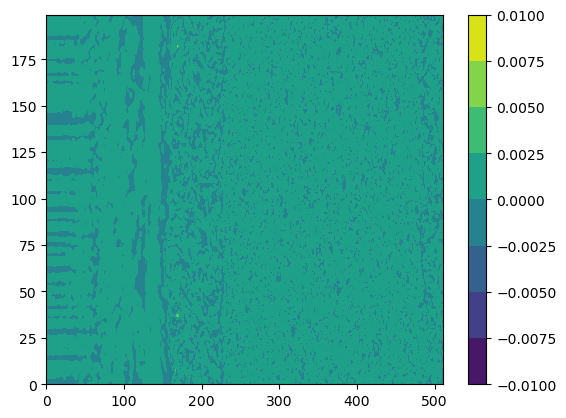

In [33]:
arr=(conv-conv2)[z]
plt.contourf(arr)
plt.colorbar()